In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
!pip install iterative-stratification

In [5]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.metrics import f1_score, classification_report, recall_score, precision_score
from sklearn.utils.class_weight import compute_class_weight
from tqdm.notebook import tqdm

# hyperparameters
PHOBERT_MODEL = "vinai/phobert-base"
MAX_LEN = 128
BATCH_SIZE = 8
NUM_EPOCHS = 10
LEARNING_RATE = 2e-5
DROPOUT = 0.3
EARLY_STOPPING = 5
ASPECT_COLS = [
    "graphics", "matchmaking", "store & microtransactions", "technical_issue",
    "mechanics", "developer_support", "event", "community", "hero_design", "difficulty"
]

CHECKPOINT_DIR = "/content/drive/MyDrive/model_IE403/checkpoints_v2"
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_model.pt")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device:{device}')

# dataset
class ASBADataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
      self.texts = texts
      self.labels = labels
      self.tokenizer = tokenizer
      self.max_len = max_len

    def __len__(self):
      return len(self.texts)

    def __getitem__(self, idx):
      text = str(self.texts.iloc[idx])
      labels = self.labels.iloc[idx].values.astype(int)
      #tokenize
      encoding = self.tokenizer(
        text,
        # nếu text > max_len -> bỏ
        truncation = True,
        # chạy GPU nên cấu hình pad để tất cả tensor trong batch cùng kích thước
        padding = "max_length",
        max_length = self.max_len,
        return_tensors = "pt"
      )
      return {
        'input_ids': encoding['input_ids'].flatten(),
        'attention_mask': encoding['attention_mask'].flatten(),
        'labels': torch.tensor(labels, dtype=torch.long)
      }

class fintunePhoBERT(nn.Module):
    def __init__(self, num_aspects=len(ASPECT_COLS), num_classes=3, dropout=DROPOUT):
      super().__init__()
      self.phobert = AutoModel.from_pretrained(PHOBERT_MODEL)
      self.dropout = nn.Dropout(dropout)
      hidder_size = self.phobert.config.hidden_size
      # dùng 10 linear head để mỗi head học lập lập và gán trọng số riêng cho từng aspect
      classifier_list = []
      for _ in range(num_aspects):
        classifier_list.append(nn.Linear(hidder_size, num_classes))
      self.classifier = nn.ModuleList(classifier_list)

    def forward(self, input_ids, attention_mask):
      outputs = self.phobert(
        input_ids = input_ids,
        attention_mask = attention_mask
      )
      # cls_output = outputs.last_hidden_state[:, 0, :]
      last_hidden = outputs.last_hidden_state
      mask = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
      masked_embeddings = last_hidden * mask
      sum_embeddings = masked_embeddings.sum(dim=1)
      sum_mask = mask.sum(dim=1).clamp(min=1e-9)
      cls_output = sum_embeddings / sum_mask
      x = self.dropout(cls_output)
      output_logits = []
      for clf in self.classifier:
        output_logits.append(clf(x))
      return output_logits

# Hàm mất mát FocalLoss để xử lý mất cân bằng dữ liệu
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce_loss = nn.functional.cross_entropy(
            logits,
            targets,
            reduction='none'
        )
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            focal_loss = alpha_t * focal_loss
        return focal_loss.mean()

# xử lý aspect imbalance tính class weight cho hàm loss
def get_criterion(df):
    criterions = []
    for col in ASPECT_COLS:
      classes = np.array([0, 1, 2])
      weights = compute_class_weight(
          class_weight="balanced",
          classes=classes,
          y=df[col].values
      )
      # gán trọng số lỗi 1 lên 3 lần
      # weights[1] = weights[1] * 3.0
      weight_tensor = torch.tensor(weights, dtype=torch.float).to(device)
      criterions.append(FocalLoss(alpha=weight_tensor, gamma=2))
    return criterions

# tính tổng loss
def loss_function(logits_list, labels, criterions):
    # logits_list: dự đoán aspect --> (batch, 3)
    # labels: nhãn thật của aspect --> (batch, 10)
    loss = 0
    for i, (logits, criterion) in enumerate(zip(logits_list, criterions)):
      loss += criterion(logits, labels[:,i])
    return loss / len(ASPECT_COLS)

def pred_per_aspect_accuracy(preds, labels):
    # preds: (batch, 10) -> nhãn dự đoán
    # label: (batch, 10) -> nhãn thật
    matches = (preds == labels)
    correct_aspect = matches.sum(dim=0)
    return correct_aspect, labels.size(0)

def train_epoch(model, loader, optimizer, scheduler, criterions):
    model.train()
    total_loss = 0
    total_correct = torch.zeros(len(ASPECT_COLS))
    total = 0
    for batch in tqdm(loader, desc="Training", leave=False):
      input_ids = batch["input_ids"].to(device)
      attention_mask = batch["attention_mask"].to(device)
      labels = batch["labels"].to(device)

      # reset gradient
      optimizer.zero_grad()
      logits_list = model(input_ids, attention_mask)
      loss = loss_function(logits_list, labels, criterions)
      # tính gradient
      loss.backward()

      # chặn gradient ko bị bùng nổ khi backprop qua nhiều lớp do có nhiều layer
      nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
      optimizer.step() # cập nhật lại trọng số
      scheduler.step() # giảm learning rate

      preds_list = []
      for l in logits_list:
          preds_list.append(l.argmax(-1))
      preds = torch.stack(preds_list, dim=1)
      correct_aspect, n = pred_per_aspect_accuracy(preds, labels)
      total_correct += correct_aspect.cpu()
      total += n
      total_loss += loss.item() * labels.size(0)
    avg_loss = total_loss / total
    aspect_accuracy = (total_correct / total).tolist()
    avg_acc = float(total_correct.sum()/ (total * len(ASPECT_COLS)))
    return avg_loss, avg_acc, aspect_accuracy

def evaluate(model, loader, criterions):
    model.eval()
    total_loss = 0
    total_correct = torch.zeros(len(ASPECT_COLS))
    total = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
      for batch in tqdm(loader, desc="Evaluating", leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits_list = model(input_ids, attention_mask)
        loss = loss_function(logits_list, labels, criterions)
        preds_list = []
        for l in logits_list:
            preds_list.append(l.argmax(-1))
        preds = torch.stack(preds_list, dim=1)
        correct_aspect,n = pred_per_aspect_accuracy(preds, labels)
        total_correct += correct_aspect.cpu()
        total_loss += loss.item() * n
        total += n
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    avg_loss = total_loss / total
    aspect_acc = (total_correct / total).tolist()
    avg_acc = float(total_correct.sum() / (total * len(ASPECT_COLS)))
    precision_aspect = []
    recall_aspect = []
    f1_aspect = []
    for i in range(len(ASPECT_COLS)):
      precision = precision_score(all_labels[:, i], all_preds[:, i], average="macro", zero_division=0)
      recall = recall_score(all_labels[:, i], all_preds[:, i], average="macro", zero_division=0)
      f1 = f1_score(all_labels[:, i], all_preds[:, i], average="macro", zero_division=0)
      precision_aspect.append(precision)
      recall_aspect.append(recall)
      f1_aspect.append(f1)
    avg_precision = float(np.mean(precision_aspect))
    avg_recall = float(np.mean(recall_aspect))
    avg_f1 = float(np.mean(f1_aspect))
    return avg_loss, avg_acc, aspect_acc, avg_precision, avg_recall, avg_f1, all_preds, all_labels, precision_aspect, recall_aspect, f1_aspect

def save_checkpoint(epoch, model, optimizer, scheduler, val_loss, val_f1, val_recall, path):
  torch.save({
    "epoch": epoch,
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "scheduler_state": scheduler.state_dict(),
    "val_loss": val_loss,
    "val_f1": val_f1,
    "val_recall": val_recall
  }, path)
  print(f"checkpoint được lưu vào {path}")

def load_checkpoint(path, model, optimizer=None, scheduler=None):
    data = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(data['model_state'])
    if optimizer:
        optimizer.load_state_dict(data["optimizer_state"])
    if scheduler:
        scheduler.load_state_dict(data["scheduler_state"])
    print(f"Load checkpoint epoch {data['epoch']} với val_f1 = {data['val_f1']:.4f}")
    return data["epoch"]

def train(df, train_df, val_df, criterions, text_col="phobert", resume=False):
    train_ds = ASBADataset(train_df[text_col], train_df[ASPECT_COLS], tokenizer)
    val_ds = ASBADataset(val_df[text_col], val_df[ASPECT_COLS], tokenizer)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)

    model = fintunePhoBERT().to(device)
    # tách weight decay khỏi gradient update giúp Phobert hộ tụ ổn định, giảm overfit và ko làm hỏng pretrain weights
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.05)
    total_steps = len(train_loader) * NUM_EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps = int(0.1 * total_steps),
        num_training_steps = total_steps
    )
    start_epoch = 0
    best_val_f1 = -1
    best_val_recall = -1
    best_val_loss = float('inf')
    no_improve = 0
    if resume and os.path.exists(BEST_MODEL_PATH):
      checkpoint_data = torch.load(BEST_MODEL_PATH, map_location=device, weights_only=False)
      start_epoch = load_checkpoint(BEST_MODEL_PATH, model, optimizer, scheduler)
      best_val_f1 = checkpoint_data.get("val_f1", -1)
      best_val_recall = checkpoint_data.get("val_recall", -1)
      best_val_loss = checkpoint_data.get("val_loss", float('inf'))
    for epoch in range(start_epoch, NUM_EPOCHS):
      print(f"Epoch {epoch+1}/{NUM_EPOCHS}:")
      train_loss, train_avg_acc, train_acc = train_epoch(model, train_loader, optimizer, scheduler, criterions)
      val_loss, val_acc, val_aspect_acc, val_precision, val_recall,val_f1, _, _,  precision_aspect, recall_aspect, f1_aspect = evaluate(model, val_loader, criterions)
      print("Train:")
      print(f"loss: {train_loss:.4f}, avg_acc_aspect: {train_avg_acc:.4f}")
      print(f"accuracy: {train_acc}")
      print("Val:")
      print(f"loss: {val_loss:.4f}, val_aspect_acc: {val_aspect_acc}")
      print(f"accuracy: {val_acc:.4f}, f1: {val_f1:.4f}, precision: {val_precision:.4f}, recall: {val_recall:.4f}")
      print("Aspect:")
      for aspect, p, r, f1 in zip(ASPECT_COLS, precision_aspect, recall_aspect, f1_aspect):
          print(f"{aspect}: f1: {f1:.4f}, precision: {p:.4f}, recall: {r:.4f}")

      # save checkpoint cho mỗi epoch
      epoch_path = os.path.join(CHECKPOINT_DIR, f"checkpoint_epoch_{epoch+1}.pt")
      save_checkpoint(epoch+1, model, optimizer, scheduler, val_loss, val_f1, val_recall, epoch_path)

      # # save best model
      if val_f1 > best_val_f1 + 1e-4: # thêm epsilon để tránh nhiễu
        best_val_f1 = val_f1
        best_val_recall = val_recall
        best_val_loss = val_loss
        no_improve = 0
        save_checkpoint(epoch + 1, model, optimizer, scheduler, val_loss, val_f1, val_recall, BEST_MODEL_PATH)
        print(f"Best model: P={val_precision:.4f}, R={val_recall:.4f}, F1={val_f1:.4f}")
      # earrly stopping theo loss
      else:
          no_improve += 1
          if no_improve >= EARLY_STOPPING:
              print(f"Early stopping tại epoch {epoch+1}")
              break
    return model

df = pd.read_csv("/content/drive/MyDrive/IE403/data_model.csv")
print(f"Total rows: {len(df)}")
print("Phân phối nhãn từng khía cạnh:")
for col in ASPECT_COLS:
    print(f"{col}: {df[col].value_counts().to_dict()}")

Using device:cuda
Total rows: 5190
Phân phối nhãn từng khía cạnh:
graphics: {0: 5012, 1: 96, 2: 82}
matchmaking: {0: 3668, 2: 1499, 1: 23}
store & microtransactions: {0: 4986, 2: 173, 1: 31}
technical_issue: {0: 2606, 2: 2569, 1: 15}
mechanics: {0: 3917, 2: 1184, 1: 89}
developer_support: {0: 3800, 2: 1022, 1: 368}
event: {0: 5111, 1: 42, 2: 37}
community: {0: 3701, 2: 1482, 1: 7}
hero_design: {0: 5007, 2: 105, 1: 78}
difficulty: {0: 5082, 2: 97, 1: 11}


In [6]:
train_path = "/content/drive/MyDrive/IE403/model_data/train_phobert.csv"
val_path = "/content/drive/MyDrive/IE403/model_data/val_phobert.csv"
test_path = "/content/drive/MyDrive/IE403/model_data/test_phobert.csv"
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)
print(f"train - val - test: {train_df.shape}, {val_df.shape}, {test_df.shape}")

train - val - test: (4152, 14), (519, 14), (519, 14)


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4152 entries, 0 to 4151
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   phobert                    4152 non-null   object
 1   graphics                   4152 non-null   int64 
 2   matchmaking                4152 non-null   int64 
 3   store & microtransactions  4152 non-null   int64 
 4   technical_issue            4152 non-null   int64 
 5   mechanics                  4152 non-null   int64 
 6   developer_support          4152 non-null   int64 
 7   sound_music                4152 non-null   int64 
 8   tutorial                   4152 non-null   int64 
 9   story                      4152 non-null   int64 
 10  event                      4152 non-null   int64 
 11  community                  4152 non-null   int64 
 12  hero_design                4152 non-null   int64 
 13  difficulty                 4152 non-null   int64 
dtypes: int64

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(PHOBERT_MODEL, use_fast=False)
criterions = get_criterion(train_df)
# train
print("training:")
model = train(df, train_df, val_df, criterions, resume=False)

training:


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/10:


Training:   0%|          | 0/519 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/65 [00:00<?, ?it/s]

Train:
loss: 0.3154, avg_acc_aspect: 0.9021
accuracy: [0.9482177495956421, 0.8921002149581909, 0.9455683827400208, 0.886801540851593, 0.8203275799751282, 0.8152697682380676, 0.9653179049491882, 0.8822254538536072, 0.9436416029930115, 0.9217244982719421]
Val:
loss: 0.5325, val_aspect_acc: [0.9210019111633301, 0.8747591376304626, 0.9113680124282837, 0.9094412326812744, 0.7919074892997742, 0.799614667892456, 0.9421965479850769, 0.8901734352111816, 0.9094412326812744, 0.8381502628326416]
accuracy: 0.8788, f1: 0.5537, precision: 0.5316, recall: 0.6612
Aspect:
graphics: f1: 0.5578, precision: 0.5442, recall: 0.7108
matchmaking: f1: 0.5705, precision: 0.5573, recall: 0.5975
store & microtransactions: f1: 0.5185, precision: 0.4848, recall: 0.6298
technical_issue: f1: 0.7196, precision: 0.7196, recall: 0.7197
mechanics: f1: 0.5005, precision: 0.4903, recall: 0.5309
developer_support: f1: 0.6991, precision: 0.6621, recall: 0.7725
event: f1: 0.4700, precision: 0.4210, recall: 0.7484
community: f1

Training:   0%|          | 0/519 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/65 [00:00<?, ?it/s]

Train:
loss: 0.2282, avg_acc_aspect: 0.9200
accuracy: [0.9636319875717163, 0.9094412326812744, 0.9556840062141418, 0.9111271500587463, 0.8482658863067627, 0.8388728499412537, 0.9790462255477905, 0.9019749760627747, 0.9547206163406372, 0.9376204013824463]
Val:
loss: 0.6585, val_aspect_acc: [0.9402697682380676, 0.9287090301513672, 0.9614643454551697, 0.8940269947052002, 0.834296703338623, 0.7957611083984375, 0.9710982441902161, 0.9113680124282837, 0.9229286909103394, 0.9190751314163208]
accuracy: 0.9079, f1: 0.5710, precision: 0.5403, recall: 0.6506
Aspect:
graphics: f1: 0.6510, precision: 0.5663, recall: 0.8583
matchmaking: f1: 0.6087, precision: 0.6033, recall: 0.6146
store & microtransactions: f1: 0.5582, precision: 0.5182, recall: 0.6255
technical_issue: f1: 0.5978, precision: 0.5973, recall: 0.5999
mechanics: f1: 0.5237, precision: 0.5082, recall: 0.5513
developer_support: f1: 0.7071, precision: 0.6755, recall: 0.7742
event: f1: 0.5354, precision: 0.4763, recall: 0.6922
community: f

In [9]:
# best model
checkpoint = torch.load(
    "/content/drive/MyDrive/model_IE403/checkpoints_v2/best_model.pt",
    map_location=device,
    weights_only=False
)
print(f"Checkpoint epoch: {checkpoint['epoch']}")
print(f"val_f1 của best model: {checkpoint['val_f1']:.4f}")

Checkpoint epoch: 5
val_f1 của best model: 0.5710


In [10]:
test_ds = ASBADataset(test_df["phobert"], test_df[ASPECT_COLS], tokenizer)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)
model = fintunePhoBERT().to(device)

# dọn VRAM cache trong GPU
torch.cuda.empty_cache()
model.load_state_dict(checkpoint["model_state"])
sentiment_label = ["Không đề cập", "Tích cực/Trung tính", "Tiêu cực"]

# evaluate trên test
test_loss, test_acc, test_aspect_acc, test_precision, test_recall, test_f1, preds, labels, precision_aspect, recall_aspect, f1_aspect = evaluate(model, test_loader, criterions)
print("Test:")
print(f"test_loss: {test_loss:.4f}")
print(f"test_acc: {test_acc:.4f}")
print(f"test_f1: {test_f1:.4f}")
print(f"test_precision: {test_precision:.4f}")
print(f"test_recall: {test_recall:.4f}")
for aspect, p, r, f1 in zip(ASPECT_COLS, precision_aspect, recall_aspect, f1_aspect):
  print(f"Aspect: {aspect}: f1: {f1:.4f}, precision: {p:.4f}, recall: {r:.4f}")

# classification report cho từng aspect
print("\nClassification Report")
for i, aspect in enumerate(ASPECT_COLS):
    present_classes = np.unique(np.concatenate([labels[:, i], preds[:, i]]))
    present_target_names = [sentiment_label[c] for c in present_classes]
    report = classification_report(
        labels[:, i], preds[:, i],
        labels=present_classes,
        target_names=present_target_names,
        zero_division=0
    )
    print(f"\n[{aspect}]\n{report}")

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Evaluating:   0%|          | 0/65 [00:00<?, ?it/s]

Test:
test_loss: 0.6648
test_acc: 0.8981
test_f1: 0.5581
test_precision: 0.5569
test_recall: 0.6032
Aspect: graphics: f1: 0.4292, precision: 0.4097, recall: 0.4728
Aspect: matchmaking: f1: 0.7446, precision: 0.9049, recall: 0.6967
Aspect: store & microtransactions: f1: 0.4843, precision: 0.4608, recall: 0.5237
Aspect: technical_issue: f1: 0.5738, precision: 0.5751, recall: 0.5741
Aspect: mechanics: f1: 0.6564, precision: 0.6593, recall: 0.6688
Aspect: developer_support: f1: 0.7060, precision: 0.6746, recall: 0.7688
Aspect: event: f1: 0.5395, precision: 0.4993, recall: 0.6817
Aspect: community: f1: 0.5840, precision: 0.5749, recall: 0.6010
Aspect: hero_design: f1: 0.4769, precision: 0.4379, recall: 0.6037
Aspect: difficulty: f1: 0.3865, precision: 0.3728, recall: 0.4404

Classification Report

[graphics]
                     precision    recall  f1-score   support

       Không đề cập       0.99      0.96      0.98       502
Tích cực/Trung tính       0.06      0.12      0.08         8
 

Nhận xét:
- mặc dù accuracy trên test đạt 89.81% nhưng chỉ số macro F1 chỉ 0.5581 cho thấy có sự chênh lệch lớn do mất cân bằng dữ liệu nghiệm trọng. Accuracy cao vì hầu hết review thuộc nhãn 0 (không đề cập) chiếm đa số. Còn F1 macro nị kéo xuống bởi những class 1 (tích cực/ trung tính) chiếm rất ít nên mô hình không nhận diện được.
- model đang có recall > precision ở hầu hết các khía cạnh trừ matchmaking, technical_issue. Điều này cho thấp model đang dự đoán thiên nhãn 2 do bị bias từ dữ liệu.

Phân tích lỗi Model

- class 1 hầu như model không học được. Dựa vào classification report cho thấy hầu hết các khía cạnh có precision = recall =F1 ~ 0.00 như graphics do aspect này chỉ có 8 mẫu tích cực trong 519 mẫu test hay matchmaking có 3 mẫu trên 519 mẫu test. Mặc dù dùng FocalLoss và class weight nhưng chưa thể xử lý triệt để tỷ lệ mất cân bằng nghiêm trọng giữa cái nhãn.
- Ngoài ra mô hình bắt đầu bị overfiting từ epoch 4 (F1 tập val giảm từ 0.5618 xuống còn 0.5537) cho thấy model đang học thuộc tập train. Vì vậy early stopping đã dừng ở epoch 5 để ngăn tình trạng overfiting và chọn model ở epoch 5 theo val F1 cao nhất là 0.5710.
- Có thể chia thành 2 nhóm khía cạnh theo hiệu suất của model:
  - matchmaking (F1=0.7446), developer_support (F1=0.7060), mechanics (F1=0.6564), community (F1=0.584), technical_issue (F1= 0.5738), event (F1=0.5395): những khía cạnh này có phân phối nhãn mặc dù vẫn mất cân bằng nhưng tỷ lệ thiểu số nhiều hơn nhóm còn lại. Ngoài ra các khía cạnh này khá rõ ràng về nhãn hơn nên model học tốt tiếng việt hơn và không dễ bị mơ hồ khi hiểu nhãn.
  - difficulty (F1=0.3865), graphics (F1=0.4292), store & microtransactions (F1=0.4843), hero_design (F1=0.4769) những khía cạnh này rất ít nhãn 1 và 2 và những khía cạnh này trong các đánh giá khá chung chung do đó model dự đoán sai nhiều hơn.

Về bản chất của PhoBERT:
- mô hình sử dụng PhoBERT làm encoder để trích xuất ngữ nghĩa câu, sau đó sử dụng nhiều classifier head riêng biệt cho từng aspect để giúp mỗi aspect học độc lập.
- Dùng CLS dể biểu diễn ngữ nghĩa của câu nhưng chỉ sử dụng 1 vector chung duy nhất cho tất cả aspect nên dễ bị trộn sentiment (đã thử và các lớp ko đề cập bị đoán thành tiêu cực do có từ tiêu cực). Do đó, dùng mean_pooling để lấy trung bình tất cả token vectors sẽ cân bằng hơn và giữ thông tin cho từng khía cạnh tốt hơn tuy nhiên cách này sẽ làm loãng thông tin, làm giảm kahr năng phân biệt aspect mơ hồ của model.
 Vì vậy mà nhãn bị mất cân bằng ở lớp 1 (tích cực/ trung tính) (cụ thể ở các cột như graphics, store & microtransactions. difficulty và hero_design bị mất cân bằng nhãn 1 và 2) nên classifier của phoBERT bị thiên về nhãn 0 vì nó chiếm đa số. Ngoài ra vì dùng chung CLS vector cho tất cả các aspect nên nếu câu review chung chung tiêu cực thì nó sẽ làm mọi aspect bị kéo về nhãn tiêu cực đặc biệt với các review chung chung.
--> Dùng FocalLoss để tính loss nhưng chỉ giảm nhẹ chứ không giải quyết triệt để.
- Do đặc thù review game rất mơ hồ và không rõ ràng về nhãn cảm xúc nên phoBERT dùng single CLS vector không hiểu được sắc thái tốt bằng những model có attention riêng cho từng khía cạnh vì vậy tahy vì không đề cập phobert có thể đoán là tiêu cực.
- Kết quả model cho thấy model đang bị bias qua lớp 2 (tiêu cực). Điều này đúng vì bộ dữ liệu đang là bộ dữ liệu review game từ 3 sao trở xuống.
- Nhược điểm của phobert là mất cân bằng nhãn nặng khi không đề cập chiếm đa số và nhãn 1 (tích cực/ trung tính) khá ít vì vậy mà model có xu hướng đoán sai các mẫu nhãn 1.


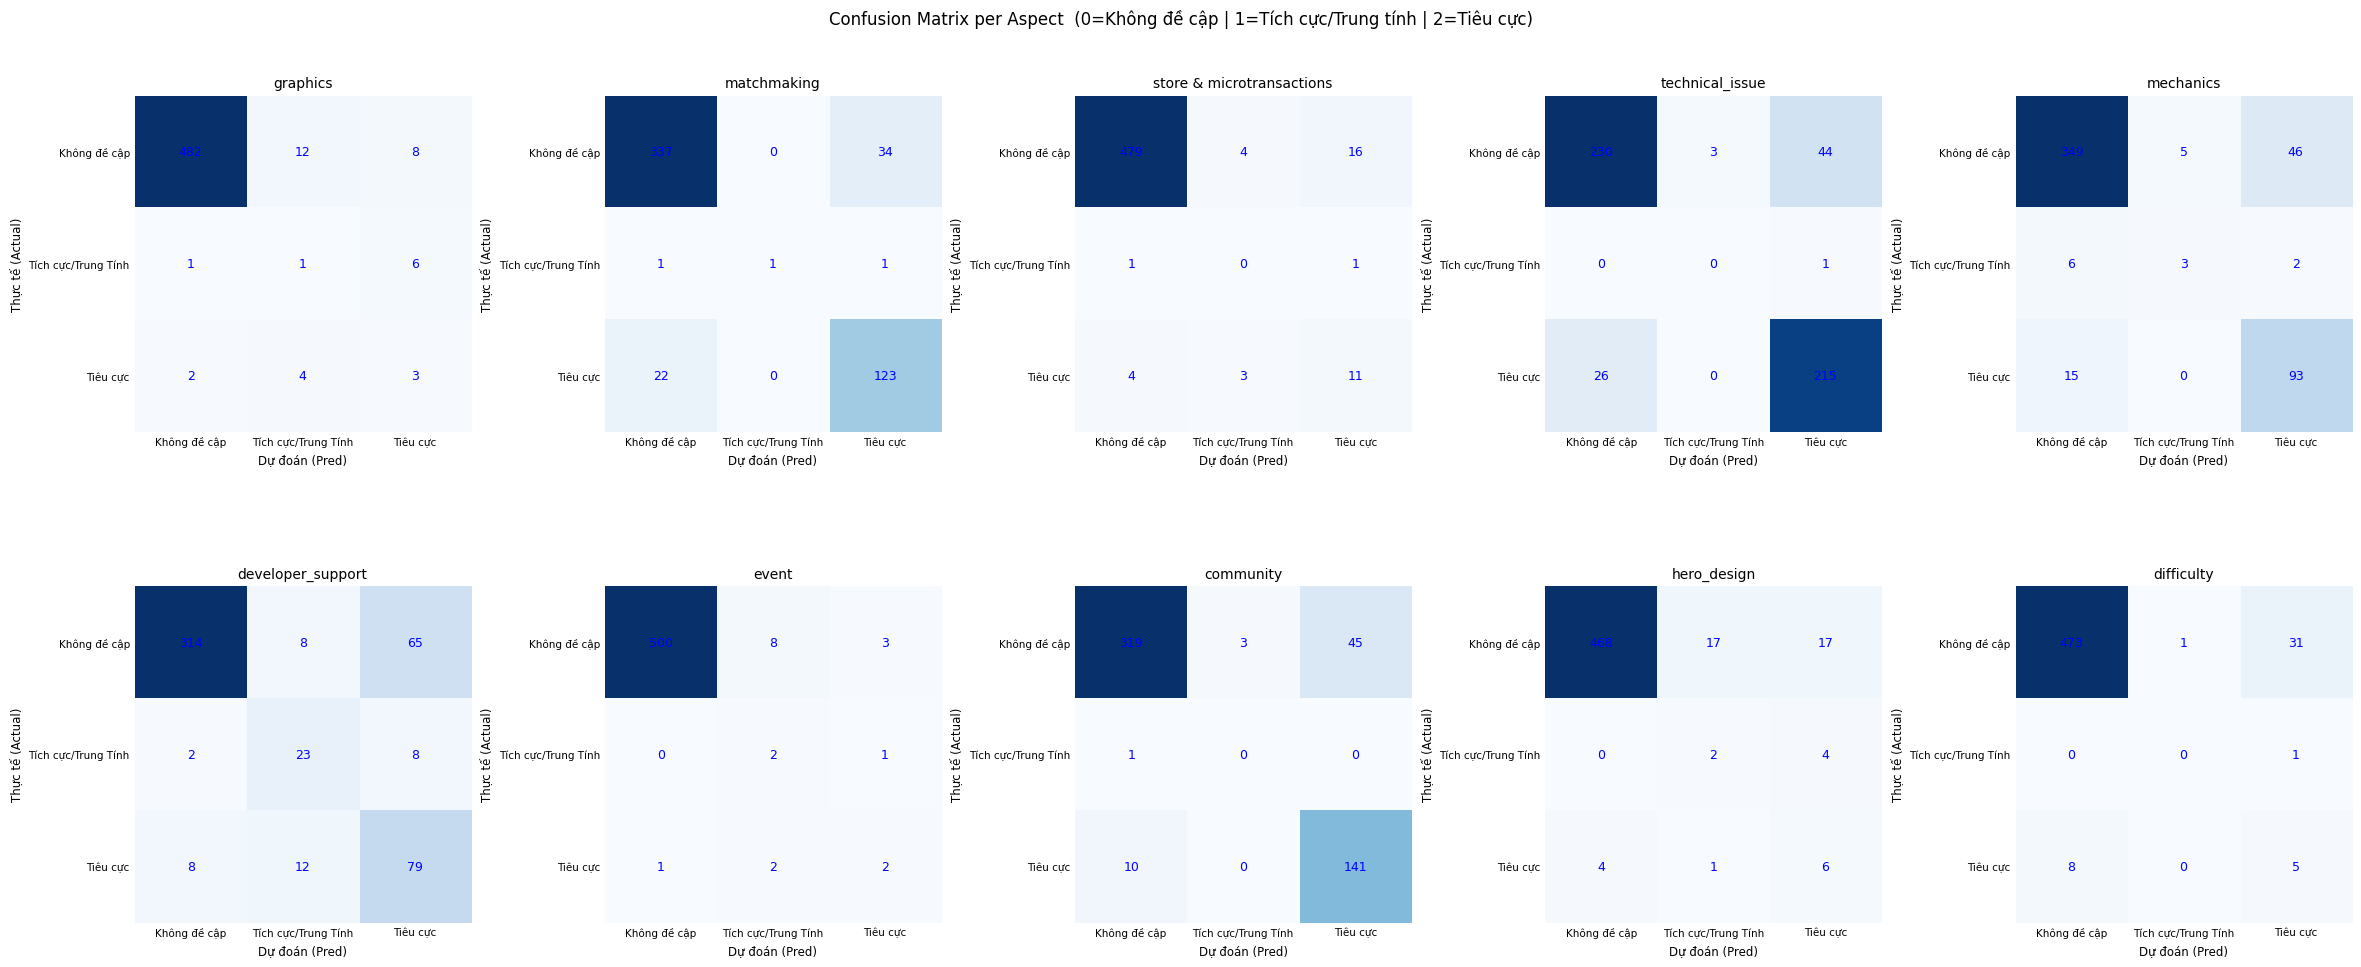

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
CLASS_LABELS = [0, 1, 2]
TICK_LABELS  = ["Không đề cập", "Tích cực/Trung Tính", "Tiêu cực"]
N_COLS = 5
n_aspects = len(ASPECT_COLS)
n_rows = (n_aspects + N_COLS - 1) // N_COLS
n_cls = len(CLASS_LABELS)
cell  = 1.1
fig_w = N_COLS * (n_cls * cell + 1.4)
fig_h = n_rows * (n_cls * cell + 1.6)
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(fig_w, fig_h), constrained_layout=True)
axes = np.array(axes).reshape(-1)
fig.suptitle("Confusion Matrix per Aspect  (0=Không đề cập | 1=Tích cực/Trung tính | 2=Tiêu cực)", y=1.01)
for idx, aspect in enumerate(ASPECT_COLS):
    ax = axes[idx]
    cm = confusion_matrix(labels[:, idx], preds[:, idx], labels=CLASS_LABELS)
    ax.imshow(cm, interpolation="nearest", cmap="Blues", vmin=0, vmax=max(cm.max(), 1))
    for i in range(n_cls):
        for j in range(n_cls):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=9, color="blue")
    ax.set_xticks(range(n_cls))
    ax.set_yticks(range(n_cls))
    ax.set_xticklabels(TICK_LABELS, fontsize=7.5)
    ax.set_yticklabels(TICK_LABELS, fontsize=7.5)
    ax.set_xlabel("Dự đoán (Pred)", fontsize=8.5)
    ax.set_ylabel("Thực tế (Actual)", fontsize=8.5)
    ax.set_title(aspect, fontsize=10, pad=6)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
for idx in range(n_aspects, len(axes)):
    axes[idx].set_visible(False)
plt.show()

- Hầu như các khía cạnh đoán đúng ở nhãn 0 nhưng sai lệch nhiều ở nhãn 1 do mất cân bằng dữ liệu vì vậy phobert không xử lý tốt dễ bị bias lớp đa số.
- khía cạnh developer_support và mechanics phobert có xu hướng đoán nhầm nhãn không đề cập thành tiêu cực và tiêu cực thành không đề cập (mechanics có 46 mẫu ko đề cập bị đoán thành tiêu cực và 15 mẫu tiêu cực bị đoán thành không đề cập, developer_support có 65 mẫu đoán từ ko đề cập thành tiêu cực và 8 mẫu tiêu cực bị đoán nhầm thành không đề cập)

Kiểm tra các review mà model dự đoán sai

In [ ]:
label = {0: "Không đề cập", 1: "Tích cực/Trung tính", 2: "Tiêu cực"}
for i in range(len(test_df["phobert"])): # Use test_df["phobert"] for texts
  for j, aspect in enumerate(ASPECT_COLS):
    true_label = labels[i][j] # Use 'labels' for y_true
    pred_label = preds[i][j]   # Use 'preds' for y_pred
    if true_label != pred_label:
      print(i)
      print(f"Aspect: {aspect}")
      print(f"True: {label[true_label]}")
      print(f"Predict: {label[pred_label]}")
      print(f"Review: {test_df["phobert"].iloc[i]}") # Use test_df["phobert"] for texts

2
Aspect: matchmaking
True: Không đề cập
Predict: Tiêu cực
Review: rep toàn gặp tệ_hại phá game
6
Aspect: store & microtransactions
True: Tiêu cực
Predict: Không đề cập
Review: game garena liên_quân ngu quá uy_tín_3.6.1 cũng bị trừ game này chán
6
Aspect: technical_issue
True: Tiêu cực
Predict: Không đề cập
Review: game garena liên_quân ngu quá uy_tín_3.6.1 cũng bị trừ game này chán
6
Aspect: mechanics
True: Không đề cập
Predict: Tiêu cực
Review: game garena liên_quân ngu quá uy_tín_3.6.1 cũng bị trừ game này chán
6
Aspect: developer_support
True: Không đề cập
Predict: Tiêu cực
Review: game garena liên_quân ngu quá uy_tín_3.6.1 cũng bị trừ game này chán
6
Aspect: community
True: Không đề cập
Predict: Tiêu cực
Review: game garena liên_quân ngu quá uy_tín_3.6.1 cũng bị trừ game này chán
8
Aspect: matchmaking
True: Tiêu cực
Predict: Không đề cập
Review: game quá_tệ trong việc xử_lí tố_cáo và hành_vi phá game , afk từ đầu đến cuối game mà không được bù_sao , rất là bức_xúc . đang chơi game

In [ ]:
incorrect_reviews_count = 0
num_reviews = labels.shape[0]
for i in range(num_reviews):
    # kiểm tra review pred sai
    if (labels[i] != preds[i]).any():
        print(f"Review {i + 1}:")
        print(f"True labels: {labels[i]}")
        print(f"Predicted labels: {preds[i]}")
        incorrect_reviews_count += 1
print(f"Tổng số review có ít nhất một khía cạnh dự đoán sai: {incorrect_reviews_count}")
print(f"Tổng số review: {num_reviews}")

Review 3:
True labels: [0 0 0 0 0 0 0 2 0 0]
Predicted labels: [0 2 0 0 0 0 0 2 0 0]
Review 7:
True labels: [0 0 2 2 0 0 0 0 0 0]
Predicted labels: [0 0 0 0 2 2 0 2 0 0]
Review 8:
True labels: [0 2 0 0 0 0 0 0 0 0]
Predicted labels: [0 2 0 0 0 0 0 2 0 0]
Review 9:
True labels: [0 2 0 2 0 2 0 2 0 0]
Predicted labels: [0 0 0 2 2 2 0 2 0 0]
Review 10:
True labels: [0 0 0 0 2 0 0 0 0 0]
Predicted labels: [0 0 0 2 2 0 0 0 0 0]
Review 12:
True labels: [0 0 0 0 0 0 0 2 0 0]
Predicted labels: [0 2 0 0 0 0 0 2 0 0]
Review 14:
True labels: [0 0 0 2 0 0 0 0 0 0]
Predicted labels: [0 0 0 2 2 0 0 0 0 0]
Review 26:
True labels: [0 0 0 0 2 0 0 0 0 2]
Predicted labels: [0 0 0 0 2 0 0 0 0 0]
Review 27:
True labels: [0 0 0 2 0 2 0 2 0 0]
Predicted labels: [0 0 0 0 1 1 0 2 0 0]
Review 28:
True labels: [0 0 0 0 2 2 0 2 0 0]
Predicted labels: [0 0 0 2 2 1 0 2 0 0]
Review 30:
True labels: [0 0 0 0 0 2 0 2 0 0]
Predicted labels: [0 2 0 0 1 1 0 2 0 0]
Review 33:
True labels: [0 0 2 0 0 0 0 0 0 0]
Predicted la

Fine-tune phoBERT với bộ dữ liệu về review game bị mất cân bằng đạt hiệu suất tốt ở các khía cạnh có phân phối ít mất cân bằng như technical_issue, developer_support hay matchmaking nhưng lại hạn chế về việc dự đoán cho các khía cạnh bị mất cân bằng nghiệm trọng. Điều này phản ánh sự đặc thù của các review game từu 3 sao trở xuống thường sẽ bị chê nhiều hơn là được khen. Do đó, nó là thách thức cho phoBERT để giải quyết.